<a href="https://colab.research.google.com/github/christian-westbrook/30-days-lost-in-space/blob/main/Visualize_Adverse.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Control

In [30]:
ATTACK = 'FGSM'
FLOORPLAN = 'glover'
TRAINING_DEVICE = 'HTC'
TESTING_DEVICE = 'HTC'

TITLE = TRAINING_DEVICE + '-' + TESTING_DEVICE + ' ' + FLOORPLAN + ' ' + ATTACK

# Merge frames

In [31]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [32]:
list_of_runs = [
    './HTC-HTC glover FGSM run 1.pkl',
    './HTC-HTC glover FGSM run 2.pkl',
    './HTC-HTC glover FGSM run 3.pkl'
]

In [33]:
def get_frame_averaged_across_runs(list_of_runs):
  list_of_frames = []

  for run in list_of_runs:
    frame = pd.read_pickle(run)
    list_of_frames.append(frame)

  mean_frame_numerics = pd.concat(list_of_frames).groupby(level=0).mean(numeric_only=True)
  mean_frame_nonnumerics = frame[["Training Device", "Testing Device", "Floorplan", "Attack", "Quantization"]]

  return mean_frame_nonnumerics.join(mean_frame_numerics)

In [34]:
results_frame = get_frame_averaged_across_runs(list_of_runs)
results_frame

,Training Device,Testing Device,Floorplan,Attack,Quantization,Sparsity,Base Error,Epsilon 0.0,Epsilon 0.1,Epsilon 0.2,Epsilon 0.3,Epsilon 0.4,Epsilon 0.5,Epsilon 0.6,Epsilon 0.7,Epsilon 0.8,Epsilon 0.9,Epsilon 1.0
0,HTC,HTC,glover,FGSM,float32,0.00,0.147632,0.147632,6.775092,9.598936,11.240136,11.801206,12.439098,12.861478,13.100041,13.480900,13.895518,14.068246
1,HTC,HTC,glover,FGSM,float32,0.25,0.054625,0.054625,5.585191,8.067280,9.412810,10.050466,10.559733,11.312450,11.585103,12.014445,12.444905,12.696318
2,HTC,HTC,glover,FGSM,float32,0.50,0.043361,0.043361,5.805445,8.150560,9.589615,10.433570,10.995786,11.184849,11.732884,12.358260,12.629739,12.953951
3,HTC,HTC,glover,FGSM,float32,0.75,0.058413,0.058413,6.119426,8.996162,10.397004,11.448696,12.275507,12.763911,13.358662,13.698670,14.112871,14.322264
4,HTC,HTC,glover,FGSM,float16,0.00,0.076343,0.076343,8.319455,12.578870,14.198769,14.643882,14.837715,15.319377,15.755428,15.755428,15.755428,15.755428
5,HTC,HTC,glover,FGSM,float16,0.25,0.058413,0.058413,7.071442,10.218422,11.584330,12.482428,13.162639,13.786551,14.574799,15.112941,15.372297,15.945454
6,HTC,HTC,glover,FGSM,float16,0.50,0.047348,0.047348,7.247620,10.594744,12.131338,13.831507,14.746837,15.524806,15.690008,16.160255,16.395063,16.678302
7,HTC,HTC,glover,FGSM,float16,0.75,0.039673,0.039673,7.617233,10.253929,12.113226,13.993962,15.301967,15.834987,16.255671,16.416207,16.565516,16.733296
8,HTC,HTC,glover,FGSM,int8,0.00,0.038594,0.038594,11.439375,15.679315,16.753034,16.951840,17.525605,17.835874,18.346892,18.346892,18.346892,18.346892
9,HTC,HTC,glover,FGSM,int8,0.25,0.061221,0.061221,6.695105,10.641600,12.310106,14.308479,15.121929,15.874861,16.635788,17.168469,17.513840,17.879384


# Base model

In [35]:
def get_location_error_list(results_frame, quantization, sparsity):
  quantization_filtered_frame = results_frame.loc[results_frame['Quantization'] == quantization]
  sparsity_filtered_frame = quantization_filtered_frame.loc[quantization_filtered_frame['Sparsity'] == sparsity]

  location_error_list = []

  for index in range(0, 11):
    epsilon = index / 10

    location_error = sparsity_filtered_frame['Epsilon ' + str(epsilon)].values[0]
    location_error_list.append(location_error)

  return location_error_list

In [36]:
location_error_data = {
    'epsilon' : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    '0.0 sparsity float32'  : get_location_error_list(results_frame, 'float32', 0.00)
}

In [37]:
location_error_frame = pd.DataFrame(data=location_error_data)
location_error_frame

,epsilon,0.0 sparsity float32
0,0.0,0.147632
1,0.1,6.775092
2,0.2,9.598936
3,0.3,11.240136
4,0.4,11.801206
5,0.5,12.439098
6,0.6,12.861478
7,0.7,13.100041
8,0.8,13.480900
9,0.9,13.895518


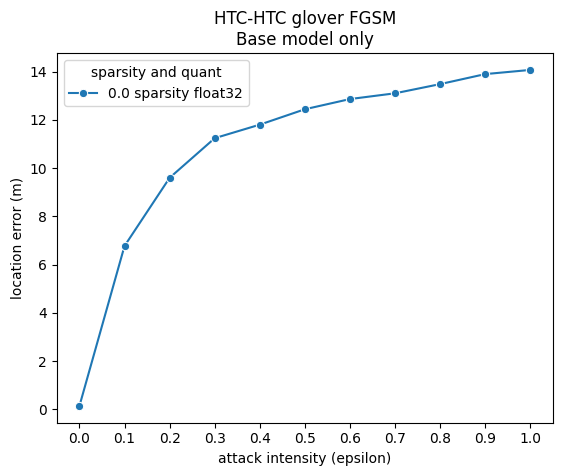

In [38]:
ax = sns.lineplot(x='epsilon', y='value', hue='variable', data=pd.melt(location_error_frame, ['epsilon']), marker='o')
ax.set(xlabel='attack intensity (epsilon)', ylabel='location error (m)', title=TITLE + '\nBase model only')

plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.legend(title="sparsity and quant")

# Sparsity and quantization individually

In [39]:
location_error_data = {
    'epsilon' : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    '0.0 sparsity float32'  : get_location_error_list(results_frame, 'float32', 0.00),
    '0.25 sparsity float32' : get_location_error_list(results_frame, 'float32', 0.25),
    '0.50 sparsity float32' : get_location_error_list(results_frame, 'float32', 0.50),
    '0.75 sparsity float32' : get_location_error_list(results_frame, 'float32', 0.75),

    '0.0 sparsity float16'  : get_location_error_list(results_frame, 'float16', 0.00),
    '0.25 sparsity float16' : get_location_error_list(results_frame, 'float16', 0.25),
    '0.50 sparsity float16' : get_location_error_list(results_frame, 'float16', 0.50),
    '0.75 sparsity float16' : get_location_error_list(results_frame, 'float16', 0.75),

    '0.0 sparsity int8'  : get_location_error_list(results_frame, 'int8', 0.00),
    '0.25 sparsity int8' : get_location_error_list(results_frame, 'int8', 0.25),
    '0.50 sparsity int8' : get_location_error_list(results_frame, 'int8', 0.50),
    '0.75 sparsity int8' : get_location_error_list(results_frame, 'int8', 0.75),
}

In [40]:
location_error_frame = pd.DataFrame(data=location_error_data)
location_error_frame

,epsilon,0.0 sparsity float32,0.25 sparsity float32,0.50 sparsity float32,0.75 sparsity float32,0.0 sparsity float16,0.25 sparsity float16,0.50 sparsity float16,0.75 sparsity float16,0.0 sparsity int8,0.25 sparsity int8,0.50 sparsity int8,0.75 sparsity int8
0,0.0,0.147632,0.054625,0.043361,0.058413,0.076343,0.058413,0.047348,0.039673,0.038594,0.061221,0.039773,0.041667
1,0.1,6.775092,5.585191,5.805445,6.119426,8.319455,7.071442,7.247620,7.617233,11.439375,6.695105,7.253930,7.678466
2,0.2,9.598936,8.067280,8.150560,8.996162,12.578870,10.218422,10.594744,10.253929,15.679315,10.641600,10.493906,9.823933
3,0.3,11.240136,9.412810,9.589615,10.397004,14.198769,11.584330,12.131338,12.113226,16.753034,12.310106,13.170936,12.671756
4,0.4,11.801206,10.050466,10.433570,11.448696,14.643882,12.482428,13.831507,13.993962,16.951840,14.308479,14.546165,14.612051
5,0.5,12.439098,10.559733,10.995786,12.275507,14.837715,13.162639,14.746837,15.301967,17.525605,15.121929,15.485985,15.792104
6,0.6,12.861478,11.312450,11.184849,12.763911,15.319377,13.786551,15.524806,15.834987,17.835874,15.874861,16.212859,16.646372
7,0.7,13.100041,11.585103,11.732884,13.358662,15.755428,14.574799,15.690008,16.255671,18.346892,16.635788,16.547746,17.110429
8,0.8,13.480900,12.014445,12.358260,13.698670,15.755428,15.112941,16.160255,16.416207,18.346892,17.168469,16.748805,17.277035
9,0.9,13.895518,12.444905,12.629739,14.112871,15.755428,15.372297,16.395063,16.565516,18.346892,17.513840,16.888679,17.412631


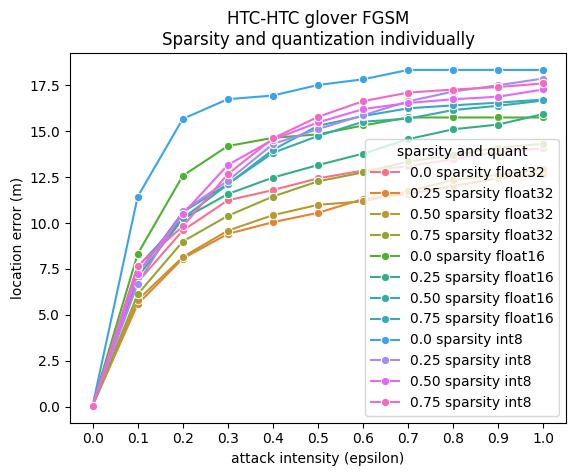

In [41]:
ax = sns.lineplot(x='epsilon', y='value', hue='variable', data=pd.melt(location_error_frame, ['epsilon']), marker='o')
ax.set(xlabel='attack intensity (epsilon)', ylabel='location error (m)', title=TITLE + '\nSparsity and quantization individually')

plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.legend(title="sparsity and quant")

In [42]:
scenario_cumulative_error_map = {}

for index, row in results_frame.iterrows():
  scenario_string = str(row['Sparsity']) + ' ' + row['Quantization']

  location_error_sum = row['Epsilon 0.0'] + row['Epsilon 0.1'] + row['Epsilon 0.2'] + row['Epsilon 0.3']
  location_error_sum = location_error_sum + row['Epsilon 0.4'] + row['Epsilon 0.5'] + row['Epsilon 0.6']
  location_error_sum = location_error_sum + row['Epsilon 0.7'] + row['Epsilon 0.8'] + row['Epsilon 0.9']
  location_error_sum = location_error_sum + row['Epsilon 1.0']

  scenario_cumulative_error_map[scenario_string] = location_error_sum

scenario_cumulative_error_map

{'0.0 float32': 119.40828382646119,
 '0.25 float32': 103.7833260484208,
 '0.5 float32': 105.87802016279299,
 '0.75 float32': 117.55158583934377,
 '0.0 float16': 142.9961217000267,
 '0.25 float16': 129.36971622517012,
 '0.5 float16': 139.04783007401582,
 '0.75 float16': 141.1256667969609,
 '0.0 int8': 169.6112046894835,
 '0.25 int8': 144.21078349959882,
 '0.5 int8': 144.67426791504437,
 '0.75 int8': 146.68061553733045}

In [43]:
sorting_data = {
    'scenario' : [],
    'cumulative error' : []
}

for key, value in scenario_cumulative_error_map.items():
  sorting_data['scenario'].append(key)
  sorting_data['cumulative error'].append(value)

In [44]:
sorting_frame = pd.DataFrame(data=sorting_data)
sorting_frame.sort_values(by='cumulative error')

,scenario,cumulative error
1,0.25 float32,103.783326
2,0.5 float32,105.878020
3,0.75 float32,117.551586
0,0.0 float32,119.408284
5,0.25 float16,129.369716
6,0.5 float16,139.047830
7,0.75 float16,141.125667
4,0.0 float16,142.996122
9,0.25 int8,144.210783
10,0.5 int8,144.674268


# Quantization with no pruning

In [45]:
location_error_data = {
    'epsilon' : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'float32'  : get_location_error_list(results_frame, 'float32', 0.00),
    'float16'  : get_location_error_list(results_frame, 'float16', 0.00),
    'int8'  : get_location_error_list(results_frame, 'int8', 0.00),
}

In [46]:
location_error_frame = pd.DataFrame(data=location_error_data)
location_error_frame

,epsilon,float32,float16,int8
0,0.0,0.147632,0.076343,0.038594
1,0.1,6.775092,8.319455,11.439375
2,0.2,9.598936,12.578870,15.679315
3,0.3,11.240136,14.198769,16.753034
4,0.4,11.801206,14.643882,16.951840
5,0.5,12.439098,14.837715,17.525605
6,0.6,12.861478,15.319377,17.835874
7,0.7,13.100041,15.755428,18.346892
8,0.8,13.480900,15.755428,18.346892
9,0.9,13.895518,15.755428,18.346892


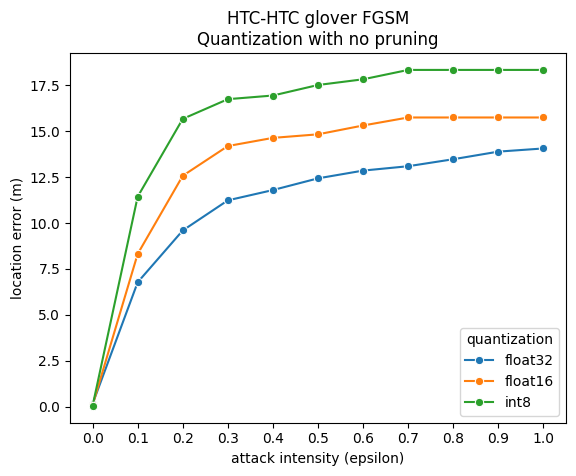

In [47]:
ax = sns.lineplot(x='epsilon', y='value', hue='variable', data=pd.melt(location_error_frame, ['epsilon']), marker='o')
ax.set(xlabel='attack intensity (epsilon)', ylabel='location error (m)', title=TITLE + '\nQuantization with no pruning')

plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.legend(title="quantization")

# Quantization across sparsities

In [48]:
average_float32_location_error = np.mean([
    get_location_error_list(results_frame, 'float32', 0.00),
    get_location_error_list(results_frame, 'float32', 0.25),
    get_location_error_list(results_frame, 'float32', 0.50),
    get_location_error_list(results_frame, 'float32', 0.75)
    ], axis=0)

average_float16_location_error = np.mean([
    get_location_error_list(results_frame, 'float16', 0.00),
    get_location_error_list(results_frame, 'float16', 0.25),
    get_location_error_list(results_frame, 'float16', 0.50),
    get_location_error_list(results_frame, 'float16', 0.75)
    ], axis=0)

average_int8_location_error = np.mean([
    get_location_error_list(results_frame, 'int8', 0.00),
    get_location_error_list(results_frame, 'int8', 0.25),
    get_location_error_list(results_frame, 'int8', 0.50),
    get_location_error_list(results_frame, 'int8', 0.75)
    ], axis=0)

In [49]:
location_error_data = {
    'epsilon' : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    'float32'  : average_float32_location_error,
    'float16' : average_float16_location_error,
    'int8' : average_int8_location_error
}

In [50]:
location_error_frame = pd.DataFrame(data=location_error_data)
location_error_frame

,epsilon,float32,float16,int8
0,0.0,0.076008,0.055444,0.045314
1,0.1,6.071289,7.563938,8.266719
2,0.2,8.703235,10.911491,11.659689
3,0.3,10.159892,12.506916,13.726458
4,0.4,10.933484,13.737945,15.104634
5,0.5,11.567531,14.512290,15.981406
6,0.6,12.030672,15.116430,16.642492
7,0.7,12.444172,15.568977,17.160214
8,0.8,12.888069,15.861208,17.385300
9,0.9,13.270758,16.022076,17.540510


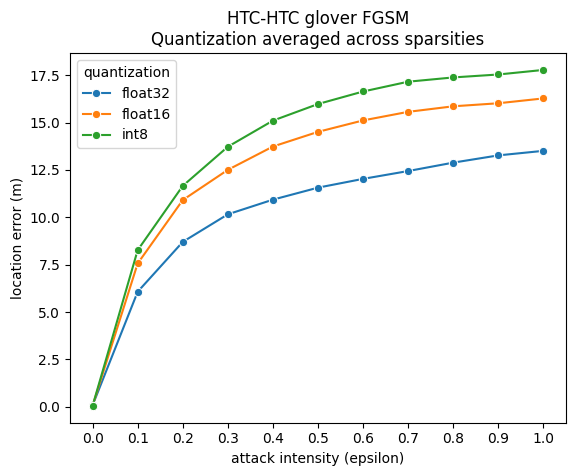

In [51]:
ax = sns.lineplot(x='epsilon', y='value', hue='variable', data=pd.melt(location_error_frame, ['epsilon']), marker='o')
ax.set(xlabel='attack intensity (epsilon)', ylabel='location error (m)', title=TITLE + '\nQuantization averaged across sparsities')

plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.legend(title="quantization")

# Sparsity with no quantization

In [52]:
location_error_data = {
    'epsilon' : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    '0.0 sparsity'  : get_location_error_list(results_frame, 'float32', 0.00),
    '0.25 sparsity' : get_location_error_list(results_frame, 'float32', 0.25),
    '0.50 sparsity' : get_location_error_list(results_frame, 'float32', 0.50),
    '0.75 sparsity' : get_location_error_list(results_frame, 'float32', 0.75),
}

In [53]:
location_error_frame = pd.DataFrame(data=location_error_data)
location_error_frame

,epsilon,0.0 sparsity,0.25 sparsity,0.50 sparsity,0.75 sparsity
0,0.0,0.147632,0.054625,0.043361,0.058413
1,0.1,6.775092,5.585191,5.805445,6.119426
2,0.2,9.598936,8.067280,8.150560,8.996162
3,0.3,11.240136,9.412810,9.589615,10.397004
4,0.4,11.801206,10.050466,10.433570,11.448696
5,0.5,12.439098,10.559733,10.995786,12.275507
6,0.6,12.861478,11.312450,11.184849,12.763911
7,0.7,13.100041,11.585103,11.732884,13.358662
8,0.8,13.480900,12.014445,12.358260,13.698670
9,0.9,13.895518,12.444905,12.629739,14.112871


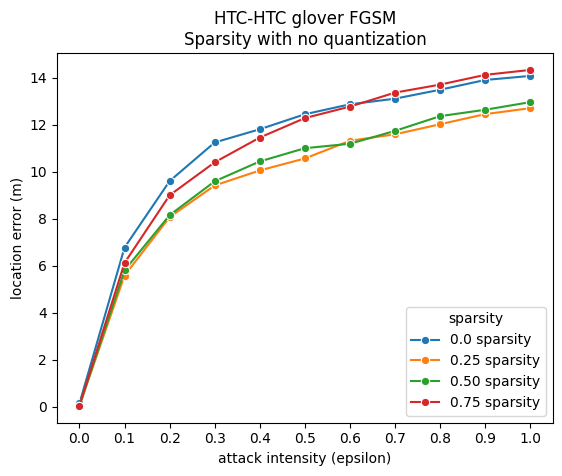

In [54]:
ax = sns.lineplot(x='epsilon', y='value', hue='variable', data=pd.melt(location_error_frame, ['epsilon']), marker='o')
ax.set(xlabel='attack intensity (epsilon)', ylabel='location error (m)', title=TITLE+ '\nSparsity with no quantization')

plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.legend(title="sparsity")

# Sparsity across quantizations

In [55]:
average_0_0_location_error = np.mean([
    get_location_error_list(results_frame, 'float32', 0.00),
    get_location_error_list(results_frame, 'float16', 0.00),
    get_location_error_list(results_frame, 'int8', 0.00),
    ], axis=0)

average_0_25_location_error = np.mean([
    get_location_error_list(results_frame, 'float32', 0.25),
    get_location_error_list(results_frame, 'float16', 0.25),
    get_location_error_list(results_frame, 'int8', 0.25),
    ], axis=0)

average_0_50_location_error = np.mean([
    get_location_error_list(results_frame, 'float32', 0.50),
    get_location_error_list(results_frame, 'float16', 0.50),
    get_location_error_list(results_frame, 'int8', 0.50),
    ], axis=0)

average_0_75_location_error = np.mean([
    get_location_error_list(results_frame, 'float32', 0.75),
    get_location_error_list(results_frame, 'float16', 0.75),
    get_location_error_list(results_frame, 'int8', 0.75),
    ], axis=0)

In [56]:
location_error_data = {
    'epsilon' : [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0],
    '0.00'  : average_0_0_location_error,
    '0.25' : average_0_25_location_error,
    '0.50' : average_0_50_location_error,
    '0.75' : average_0_75_location_error
}

In [57]:
location_error_frame = pd.DataFrame(data=location_error_data)
location_error_frame

,epsilon,0.00,0.25,0.50,0.75
0,0.0,0.087523,0.058087,0.043494,0.046584
1,0.1,8.844641,6.450579,6.768998,7.138375
2,0.2,12.619040,9.642434,9.746403,9.691342
3,0.3,14.063980,11.102416,11.630630,11.727329
4,0.4,14.465643,12.280458,12.937081,13.351569
5,0.5,14.934139,12.948100,13.742869,14.456526
6,0.6,15.338910,13.657954,14.307505,15.081757
7,0.7,15.734120,14.265230,14.656879,15.574921
8,0.8,15.861073,14.765285,15.089107,15.797304
9,0.9,15.999279,15.110347,15.304494,16.030339


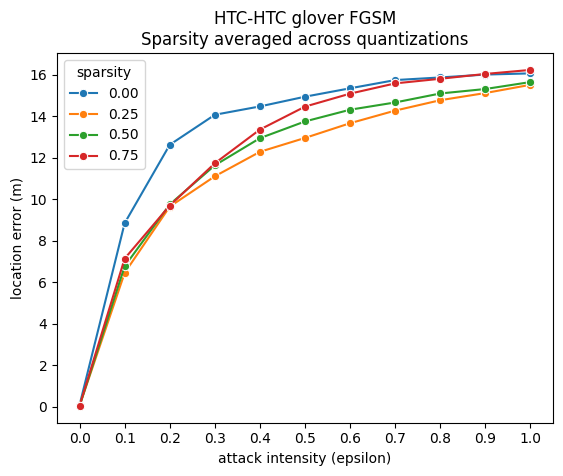

In [58]:
ax = sns.lineplot(x='epsilon', y='value', hue='variable', data=pd.melt(location_error_frame, ['epsilon']), marker='o')
ax.set(xlabel='attack intensity (epsilon)', ylabel='location error (m)', title=TITLE + '\nSparsity averaged across quantizations')

plt.xticks(np.arange(0.0, 1.1, 0.1))
plt.legend(title="sparsity")